# Time Series Forecasting (Utility Sector)
Prepared by: **Jacinto, Melchor R.** \
Last modified: 29 March 2026



## Overview
This notebook documents the development of time series forecasts using an 8-year, daily historical [data](https://github.com/mrjacinto/experiments/blob/main/time-series-forecasting/datasources/) (Jan 2015 - Dec 2022) of a highly regulated utility sector. The primary objective is to build a predictive model capable of generating a full-year forecast to assist in a suite of business use-cases (e.g. operational planning, resource allocation, etc.).

## Objectives
* **Forecasting:** Develop a robust forecast based on historical patterns.
  * Model development:
    * Provide daily forecast from Jul 1 - Dec 31, 2022.
    * Test model performance using *Mean Absolute Percent Error* (MAPE) and *Root Mean Squared Error* (RMSE).
  * Forecast generation:
    * Generate a full-year (2023) daily forecast using the best performing model.
    * Provide aggregated monthly forecast for the same period.
* **Insight Generation:** Extract actionable insights from the model's predictions.
* **Strategic Recommendations:** Provide a framework for developing a robust forecasting model.

In [1]:
%%capture
# Install dependencies
!pip install colabtools statsforecast utilsforecast prophet

# Load rpy2 extension to run R scripts in this notebook
%load_ext rpy2.ipython

In [2]:
# Import libraries

# Data manipulation
import numpy as np
import pandas as pd
from pandas import DataFrame
from datetime import datetime, timedelta

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, \
SeasonalNaive, SeasonalWindowAverage, ARIMA, AutoARIMA, TBATS, AutoTBATS, \
DynamicOptimizedTheta, Theta, AutoTheta, AutoETS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

# Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
%%capture
%%R
# Install and load R library
install.packages('psych')
library(psych) # pairwise relationships

## Import the data
The data is uploaded in a github [repo](https://github.com/mrjacinto/experiments/blob/main/time-series-forecasting/datasources/) for ease of import to this colab notebook. It contains the following information:

 * **Date**: daily historical data from Jan 2015 - Dec 2022 (8 full years). This will be used as the time series index (`date`) for this exercise.
 * **X variables (regressors)**: five (5) independent variables (`x1 - x5`) that will be used as input variables to train the model.
 * **Y variable (regressand)**: a dependent variable (`y`) to predict.

Note: The data is conveniently split into 7.5 years of historical data for training (`x_train.csv, y_train.csv`), and half year (6 months) data for testing (`x_test.csv, y_test.csv`).

In [4]:
# Import data from github
data_urls = {
    'x_train': 'https://raw.githubusercontent.com/mrjacinto/experiments/refs/heads/main/time-series-forecasting/datasources/x_train.csv',
    'y_train': 'https://raw.githubusercontent.com/mrjacinto/experiments/refs/heads/main/time-series-forecasting/datasources/y_train.csv',
    'x_test': 'https://raw.githubusercontent.com/mrjacinto/experiments/refs/heads/main/time-series-forecasting/datasources/x_test.csv',
    'y_test': 'https://raw.githubusercontent.com/mrjacinto/experiments/refs/heads/main/time-series-forecasting/datasources/y_test.csv'
}

# Convert each url to a pandas dataframe
# Assign `date` as the index column (important for time series data)
for var_name, url in data_urls.items():
    globals()[var_name] = pd.read_csv(url, parse_dates=["date"], index_col="date")

## Exploratory Data Analysis

### Summary statistics
Before doing any forecasting work, it is important to visualize the data to explore patterns and/or relationships across different variables.

The next few code blocks will show some exploratory data screening to understand the patterns in the data (i.e. measures of central tendency and dispersion, preliminary visualization of predictor and response variables, etc.).

*Some takeaways*:
* Most, if not all, variables show similar/symmetrical distributions between train and test sets, which gives us an indication that the model is likely to generalize well.
* No missing values observed across all variables.
* Data points across variables are generally consistent except `x3` and `y`, where data points are more spread out (looking at the boxplots and *std* in relation to the *mean*).
* Some variables (e.g. `x4` and `x5`) would need to be transformed during the model training since they seem to operate on a much higher scales than the others.
* The data seem to exhibit strong seasonal patterns (series charts and boxplots).
* Some outliers are observed, which is not uncommon in the utility sector. At this point, I'm not inclined to removing these observations since some advanced models are robust enough to handle the outliers well.

Note: The rationale for comparing the measures of central tendency and dispersion between train and test sets is to ensure that the training data meets the foundational assumptions in any machine learning (or forecasting) work.

In [5]:
# Set global variables
# Define the list of variables
variables = ['x1', 'x2', 'x3', 'x4', 'x5', 'y']

# Combine x, y train and test sets
# This will be used for comparing summary statistics between train and test sets
df_train = pd.concat([x_train, y_train], axis=1)
df_test = pd.concat([x_test, y_test], axis=1)

# Combine everything into one long-form dataframe
# This will be used for plotting and other use-cases
df_combined = pd.concat([df_train, df_test])

In [6]:
# Compare summary statistics of train and test sets

# This function gets the summary statistics of train and test sets
def get_summary_statistics(train, test):

    # Calculate statistics (transpose to apply formatting loop)
    train_stats = train[variables].describe().T
    test_stats = test[variables].describe().T

    # Add new column to get missing value counts
    train_stats['missing'] = train[variables].isnull().sum()
    test_stats['missing'] = test[variables].isnull().sum()

    # Format `count` and `missing` as int; the rest as float (.2f)
    cols_to_round = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']

    for stats in [train_stats, test_stats]:
        stats[cols_to_round] = stats[cols_to_round].round(2)
        stats[['count', 'missing']] = stats[['count', 'missing']].astype(int)

    return train_stats, test_stats

# Run summary stats
train_summary, test_summary = get_summary_statistics(df_train, df_test)

print("--- Training Set Summary Statistics ---")
display(train_summary)

print("\n--- Testing Set Summary Statistics ---")
display(test_summary)

--- Training Set Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max,missing
x1,2738,33.09,2.76,23.40,31.02,33.30,35.20,39.80,0
x2,2738,28.57,1.52,22.50,27.50,28.50,29.60,32.70,0
x3,2738,2.09,3.68,0.00,0.00,0.00,3.00,23.00,0
x4,2738,114.11,40.34,32.00,84.00,110.00,139.00,319.00,0
x5,2738,728.26,35.72,676.00,693.00,729.00,763.00,780.00,0
y,2738,-9.20,174.49,-567.02,-138.03,-9.07,128.66,423.23,0



--- Testing Set Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max,missing
x1,184,32.69,1.99,26.90,31.70,32.70,33.90,37.60,0
x2,184,28.16,1.10,25.10,27.58,28.20,28.90,30.70,0
x3,184,3.11,3.44,0.00,0.00,2.00,5.00,19.00,0
x4,184,121.84,34.41,58.00,100.00,115.00,138.00,279.00,0
x5,184,722.50,35.31,676.00,687.75,720.50,756.00,779.00,0
y,184,95.00,165.03,-440.47,-34.98,92.51,238.42,404.86,0


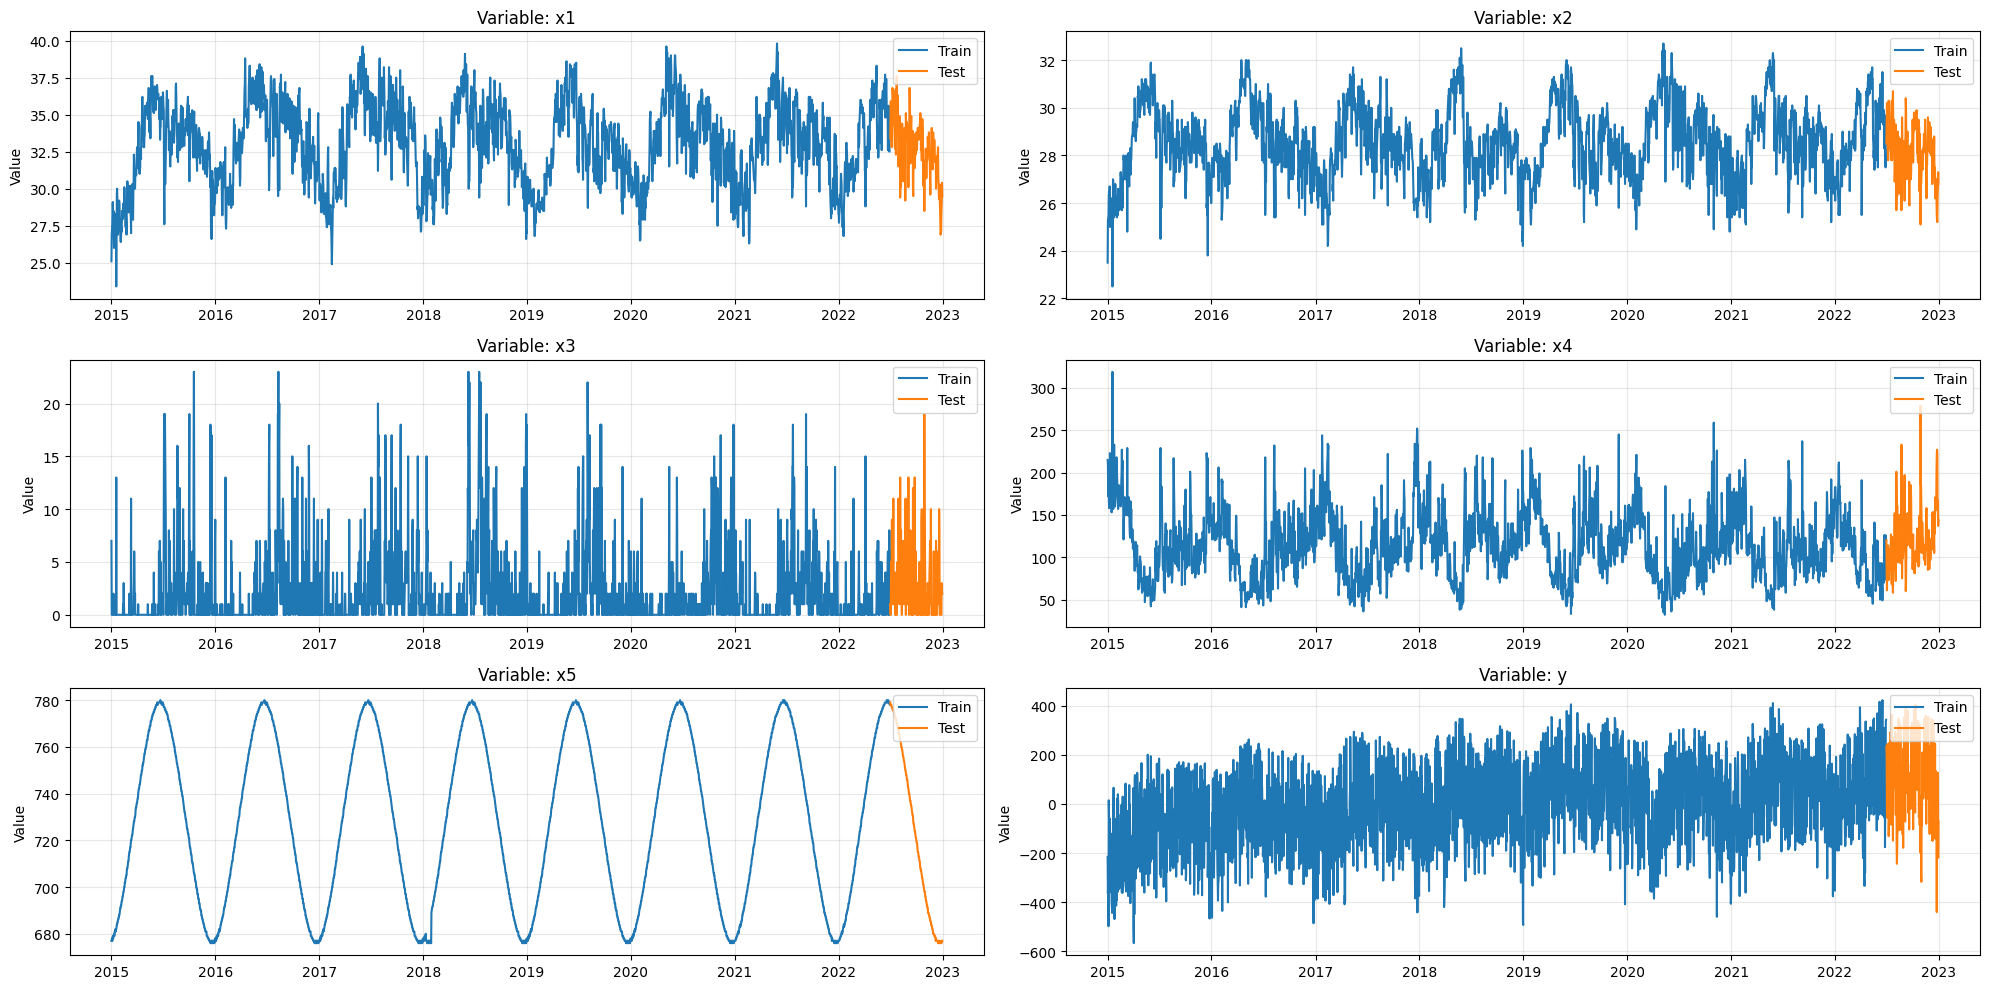

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(20, 10))
axes = axes.flatten()

# Use the index of df_train and df_test to split the view
train_idx = df_train.index
test_idx = df_test.index

for i, var in enumerate(variables):
    # Plot Train and Test from the combined dataframe
    axes[i].plot(train_idx, df_combined.loc[train_idx, var], label='Train', color='tab:blue')
    axes[i].plot(test_idx, df_combined.loc[test_idx, var], label='Test', color='tab:orange')

    # Formatting
    axes[i].set_title(f'Variable: {var}')
    axes[i].set_ylabel('Value')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

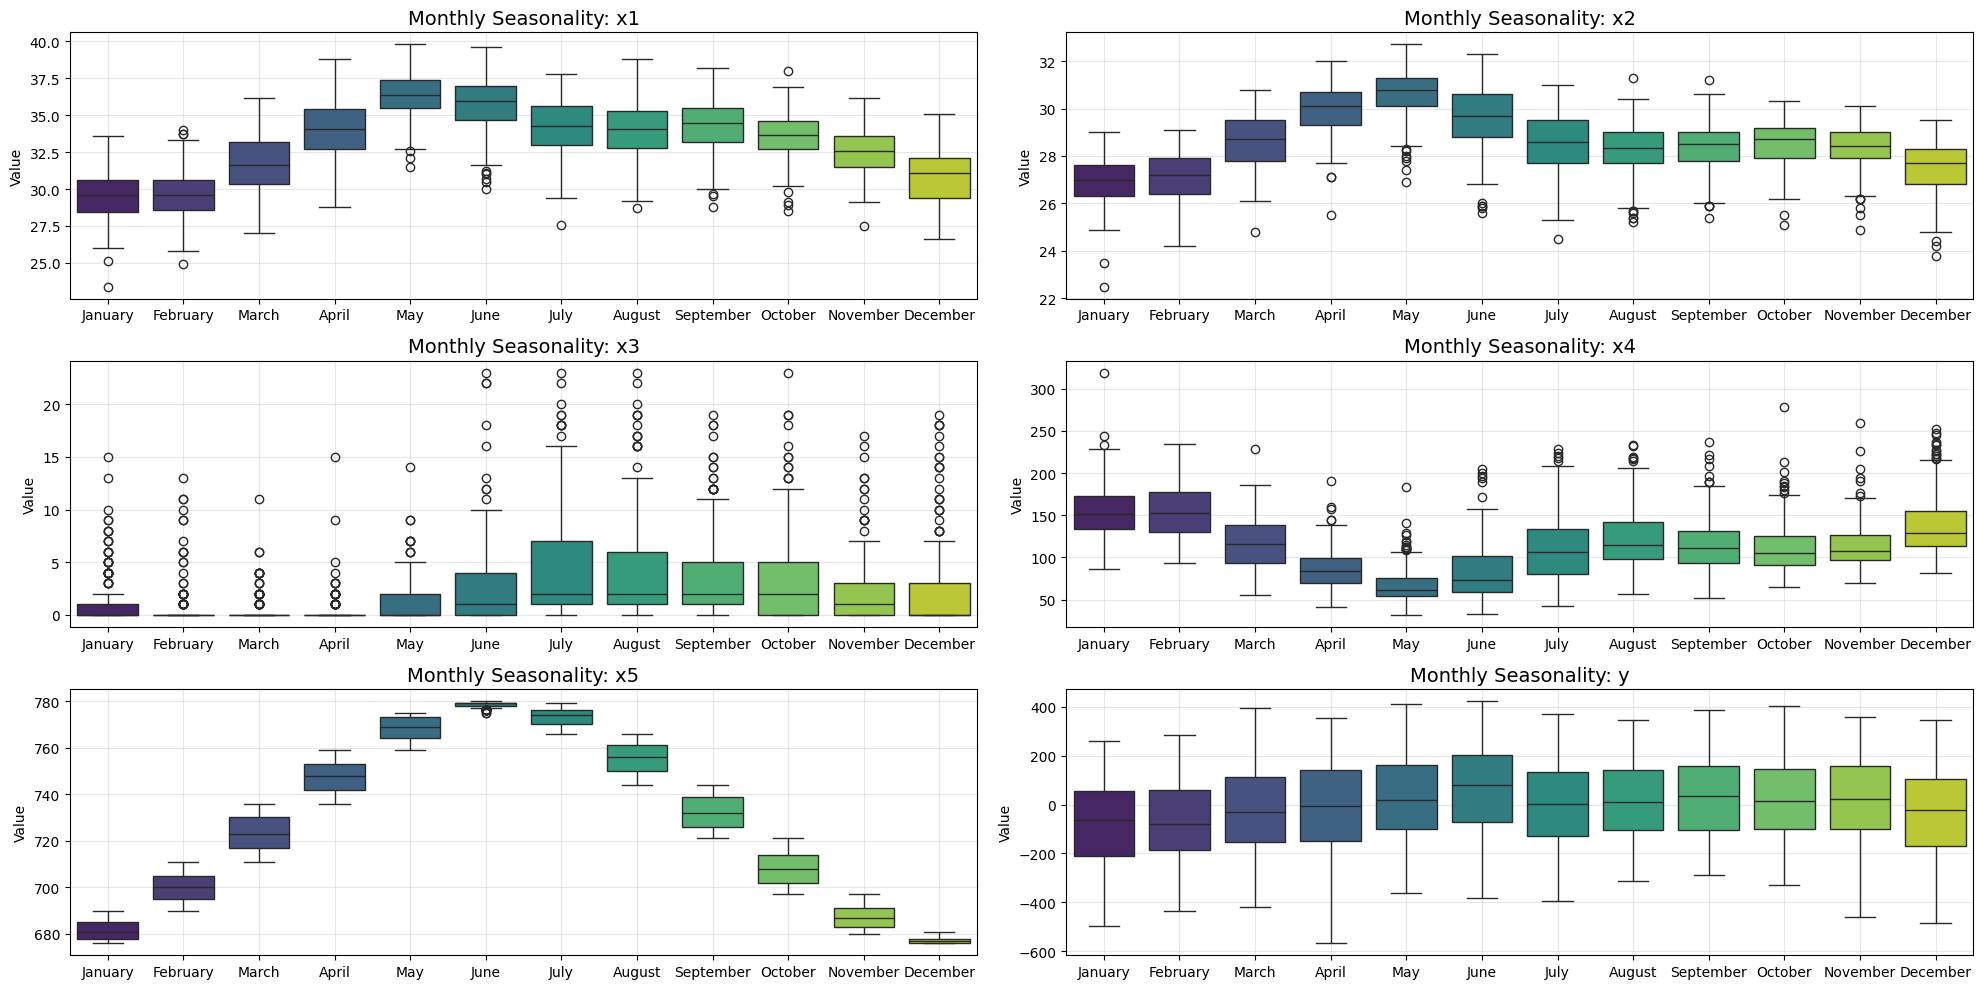

In [8]:
# Data for seasonal plots
df_seasonal = df_combined.copy()
df_seasonal['Month'] = df_seasonal.index.month_name()

# Order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(3, 2, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(x='Month', y=var, data=df_seasonal, ax=axes[i], order=month_order, palette='viridis')
    axes[i].set_title(f'Monthly Seasonality: {var}', fontsize=14)
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Multicollinearity
The time series charts and boxplots reveal rich information about the underlying patterns in the data.

For instance, the predictor variables `x1`, `x2`, and `x5` seem to peak during the summer months (Apr - Jul) and dip during the winter (Dec - Feb). Conversely, `x3` and `x4` seem to dip during early summer (Apr/May) while remaining relatively constant throughout the year.

Whenever possible, we need to avoid using multicollinear variables (i.e. two or more predictor variables that are highly correlated with each other) as input when training a model as it often provides unreliable model estimates (coefficients).

Here, I further investigated the strength (or lack thereof) of these relationships in the next code blocks.

* We can see that variables `x1` and `x2` have a strong positive relationship (*r = 0.86*). Similarly, both variables have moderate positive relationships with `x5` (*r =0.66 and 0.54*, respectively).
* On the other hand, variable `x4` shows strong negative relationship with `x1` (*r = -0.84*) and `x2` (*r = -0.93*), while moderate negative relationship with `x5` (*r = -0.49*).
* Shape of the distribution is relatively normal across variables except `x3` and `x5`, where you frequently have extreme values on either (or both) sides.
* Initial diagnosis of variance across all predictors showed high variance inflation factor (VIF) in `x2`. High VIF (generally, greater than **10**) makes the coefficients poorly estimated and likely unreliable.
* Removing `x2` in the second VIF run showed relatively stable values (*< 5*).

For this reason, we will fit the data to a multivariate model without the variable `x2` to prevent it from generating unreliable forecasts.

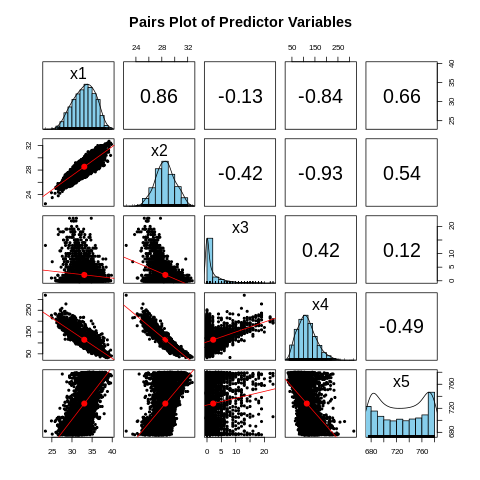

In [9]:
%%R -i df_combined
pairs.panels(df_combined[,1:5], # predictor variables only
             method = "pearson", # correlation method
             hist.col = "skyblue",
             lm = TRUE, # add linear regression line
             density = TRUE,  # show density plots
             ellipses = TRUE, # show correlation ellipses
             main = "Pairs Plot of Predictor Variables"
             )

In [10]:
# Calculate the variance inflation factor (VIF) across predictor variables
df_vif = df_combined[['x1', 'x2', 'x3', 'x4', 'x5']].copy()
df_vif['x4'] = np.log1p(df_vif['x4'])
df_vif['x5'] = np.log1p(df_vif['x5'])

# Add constant for VIF calculation
X = add_constant(df_vif)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# Re-doing the VIF without `x2`
df_vif_no_x2 = df_vif.drop(['x2'], axis = 1)
Y = add_constant(df_vif_no_x2)

# Calculate VIF for each feature
vif_data_no_x2 = pd.DataFrame()
vif_data_no_x2["feature"] = Y.columns
vif_data_no_x2["VIF"] = [variance_inflation_factor(Y.values, i) for i in range(len(Y.columns))]

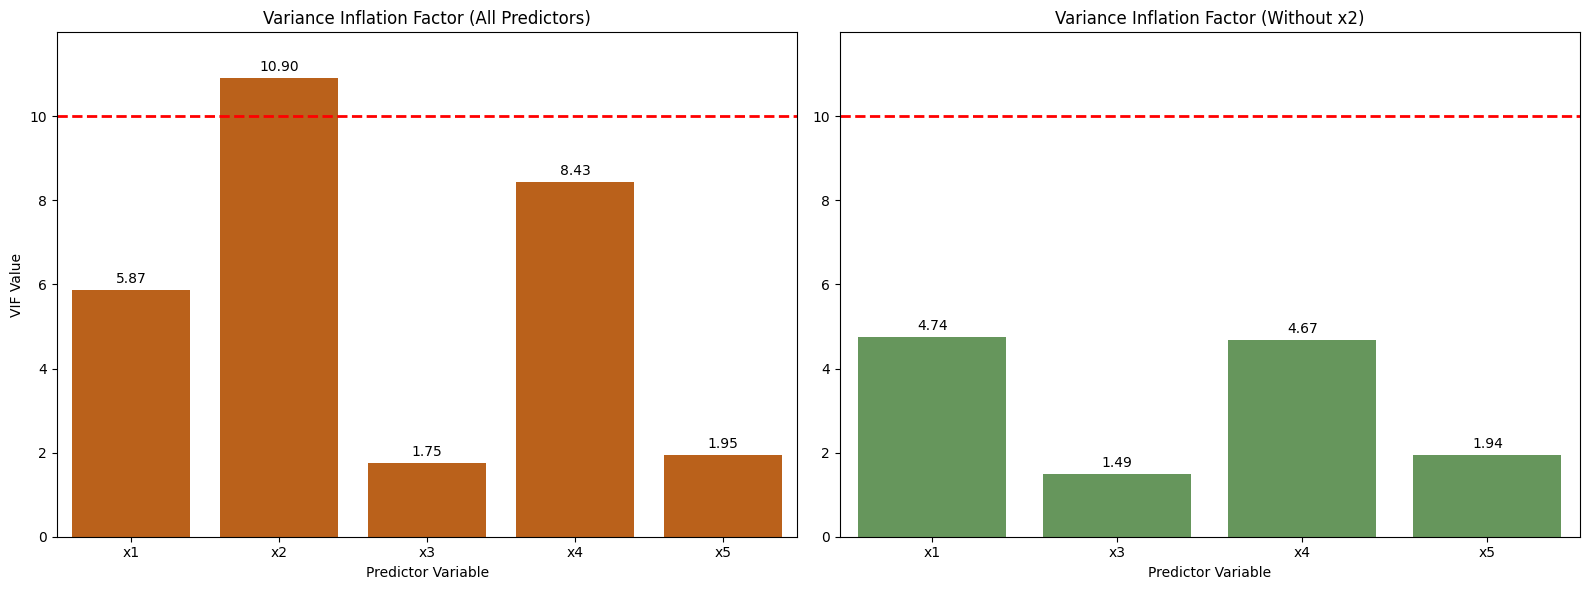

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Max VIF to be used as a common y-axis limit to illustrate how removing
# highly correlated variable(s) stabilize VIF across predictors
max_vif = max(vif_data[vif_data['feature'] != 'const']['VIF'].max(),
              vif_data_no_x2[vif_data_no_x2['feature'] != 'const']['VIF'].max())

# Plot VIF for all predictors
sns.barplot(x='feature', y='VIF', data=vif_data[vif_data['feature'] != 'const'], ax=axes[0], color='#d55e00')
axes[0].set_title('Variance Inflation Factor (All Predictors)')
axes[0].set_xlabel('Predictor Variable')
axes[0].set_ylabel('VIF Value')
axes[0].set_ylim(0, max_vif * 1.1)  # Set common y-axis limit + small buffer
axes[0].grid(axis='y', alpha=0)
axes[0].axhline(10, color='red', linestyle='--', linewidth=2) # > 10 suggests high multicollinearity
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', label_type='edge', padding=3)

# Plot VIF without x2
sns.barplot(x='feature', y='VIF', data=vif_data_no_x2[vif_data_no_x2['feature'] != 'const'], ax=axes[1], color='#5FA052')
axes[1].set_title('Variance Inflation Factor (Without x2)')
axes[1].set_xlabel('Predictor Variable')
axes[1].set_ylabel('')
axes[1].set_ylim(0, max_vif * 1.1)
axes[1].grid(axis='y', alpha=0)
axes[1].axhline(10, color='red', linestyle='--', linewidth=2)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

# Train Model

## Benchmark: Univariate time series
For the purposes of this exercise, I used some classic univariate baseline (i.e. *`Naive`*, *`Historic Average`*, *`Window Average`*, *`Seasonal Naive`*, and *`Seasonal Window Average`*) and advanced time series models (*`AutoTheta`*, *`AutoARIMA`*, *`AutoTBATS`*, *`AutoETS`*, and *`DynamicOptimizedTheta`*) to establish a performance benchmark.

* `AutoTBATS` and `DynamicOptimizedTheta` seem to perform well (least RMSEs) among their peers of benchmark models.
* Baseline models `Naive` and `SeasonalNaive` are the worst performing (highest RMSEs).

*PS. I used the model family of automatic forecasting (with `Auto` prefix) to automatically search for the best parameters of each time series model.*

In [12]:
%%time
# Prepare data for statsforecast: needs columns [unique_id, ds, y]
# Create `unique_id` variable (required for statsforecast)
train_sf = df_train[['y']].reset_index().rename(columns={'date': 'ds', 'y': 'y'})
train_sf['unique_id'] = 'series1'

test_sf = df_test[['y']].reset_index().rename(columns={'date': 'ds', 'y': 'y'})
test_sf['unique_id'] = 'series1'

# Define models
models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=30),
    SeasonalNaive(season_length=7),
    SeasonalWindowAverage(season_length=7, window_size=7),
    AutoTheta(),
    AutoARIMA(),
    AutoTBATS(season_length=7),
    AutoETS(),
    DynamicOptimizedTheta(season_length=7, decomposition_type='additive')
]

# Instantiate and fit StatsForecast
sf = StatsForecast(models=models, freq='D', n_jobs=-1)
sf.fit(train_sf)

# Generate forecasts for 6 months (length of test set)
forecast_baseline = sf.predict(h=len(df_test))

# Merge with actual values for evaluation
evaluation_df = forecast_baseline.merge(test_sf, on=['unique_id', 'ds'], how='left')

CPU times: user 32.5 s, sys: 464 ms, total: 33 s
Wall time: 32.5 s


In [13]:
model_names = ['Naive', 'HistoricAverage', 'WindowAverage', 'SeasonalNaive', \
               'SeasWA', 'AutoTheta', 'AutoARIMA', 'AutoTBATS', \
               'AutoETS', 'DynamicOptimizedTheta']
metrics = []

for model in model_names:
    mape = mean_absolute_percentage_error(evaluation_df['y'], evaluation_df[model]) * 100
    rmse = root_mean_squared_error(evaluation_df['y'], evaluation_df[model])
    metrics.append({'Model': model, 'MAPE': mape, 'RMSE': rmse})

# Store evaluation metrics in metrics_df
metrics_df = pd.DataFrame(metrics)

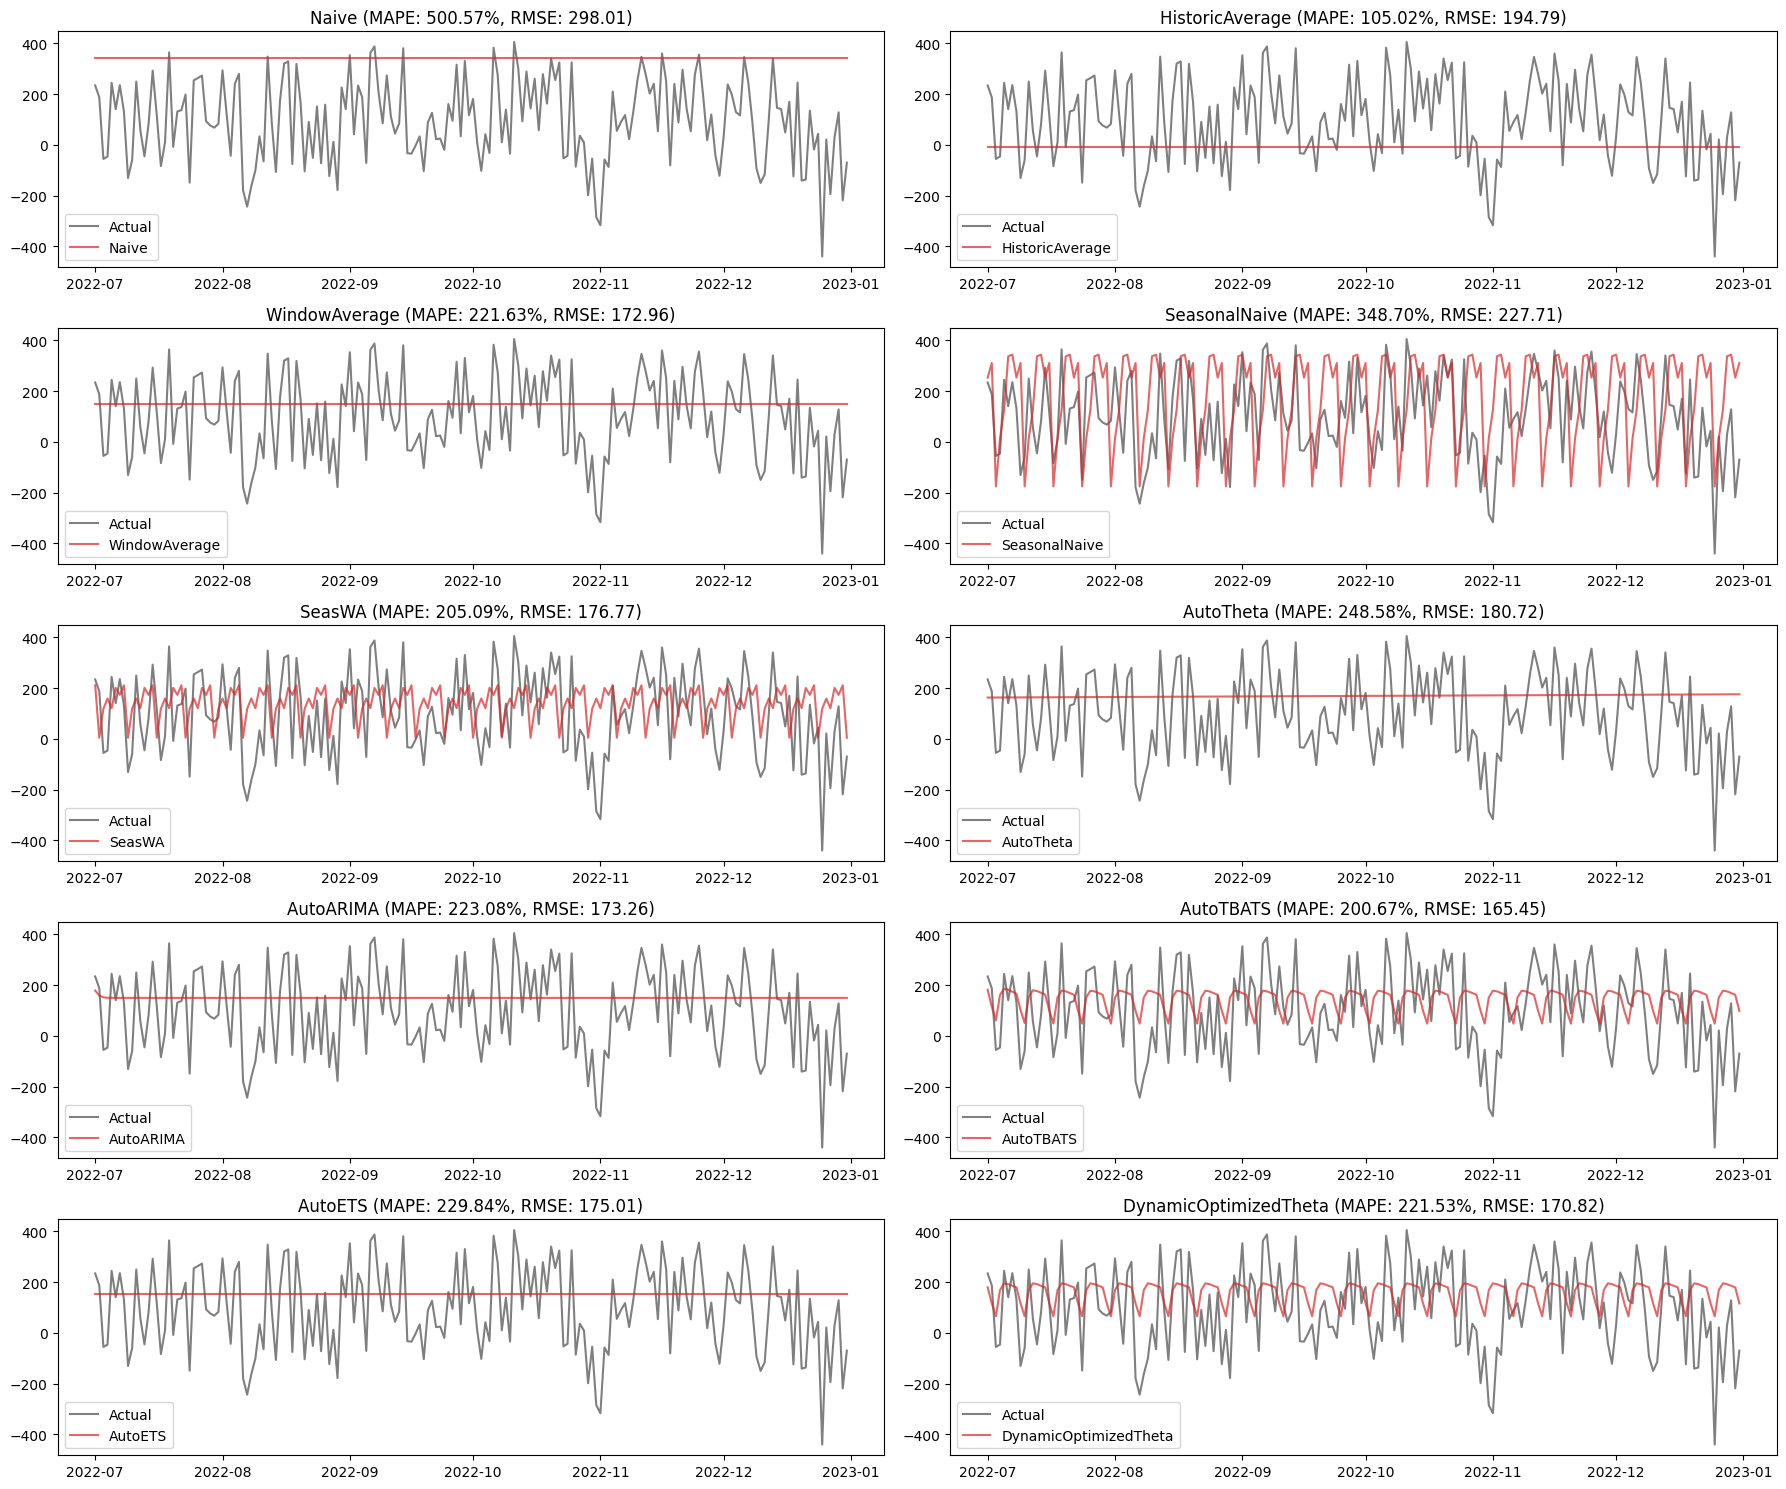

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(18, 15))
axes = axes.flatten()

for i, model in enumerate(model_names):
    # Extract metrics for the current model
    model_metrics = metrics_df[metrics_df['Model'] == model].iloc[0]
    mape_val = model_metrics['MAPE']
    rmse_val = model_metrics['RMSE']

    axes[i].plot(evaluation_df['ds'], evaluation_df['y'], label='Actual', color='black', alpha=0.5, linewidth=1.5)
    axes[i].plot(evaluation_df['ds'], evaluation_df[model], label=f'{model}', alpha=0.7, color='tab:red')

    # Include evaluation metrics in the title
    axes[i].set_title(f'{model} (MAPE: {mape_val:.2f}%, RMSE: {rmse_val:.2f})', fontsize=12)
    axes[i].legend(loc='lower left')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

## Multivariate time series models

Now that we've established a benchmark, I'm going to use two (2) time series models that allow multiple variables as input (`x1 - x5`) to predict a target output (`y`).

* As observed in an earlier diagnostic, I removed the variable `x2` to eliminate (or minimize) the effect of multicollinearity when fitting the model to the data.
* Variables `x4` and `x5` are transformed to ensure that no single feature dominates during the model training.
* I used `additive` seasonality since the magnitude of the seasonal fluctuation seems to remain constant over time (as shown in the previous series charts).
* Forecasts using *`Prophet`* seem to generalize well, compared the *`XGBoost`* where the forecasts tend to capture the noise in the historical data. Moreover, prediction intervals (80%) in *`XGBoost`* miss some extreme values in the test set.
* Evaluation metrics showed *`Prophet`* as a better model in comparison with *`XGBoost`* and other benchmark models.

In [15]:
%%time
# Prophet requires columns 'ds' (datetime) and 'y' (target variable)

# Training data (Prophet)
prophet_train_df = df_train.reset_index().rename(columns={'date': 'ds', 'y': 'y'})

# Apply log transformation to x4 and x5 as done during VIF check
prophet_train_df['x4'] = np.log1p(prophet_train_df['x4'])
prophet_train_df['x5'] = np.log1p(prophet_train_df['x5'])

# Select regressors (excluding x2)
regressors = ['x1', 'x3', 'x4', 'x5']

# Initialize Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False, # Daily data, but not within-day patterns
    seasonality_mode='additive'
)

# Add regressors to the model
for regressor in regressors:
    model.add_regressor(regressor)

# Fit the model to the training data
model.fit(prophet_train_df[['ds', 'y'] + regressors])

CPU times: user 276 ms, sys: 7.98 ms, total: 284 ms
Wall time: 452 ms


In [16]:
# Create a dataframe for future predictions, covering the test period
future = model.make_future_dataframe(
    periods=len(df_test),
    freq='D',
    include_history=False # Only generate dates for the prediction period
)

# Prepare the test regressors (excluding x2)
x_test_for_prophet = df_test[regressors].copy()
x_test_for_prophet = x_test_for_prophet.reset_index().rename(columns={'date': 'ds'})

# Apply log transformation to x4 and x5 in the test set
x_test_for_prophet['x4'] = np.log1p(x_test_for_prophet['x4'])
x_test_for_prophet['x5'] = np.log1p(x_test_for_prophet['x5'])

# Merge regressors into the future dataframe
future = pd.merge(future, x_test_for_prophet, on='ds', how='left')

# Predict and extract values for the test period
forecast = model.predict(future)
y_pred = forecast[['ds', 'yhat']].set_index('ds')

# Align actual and predicted values for evaluation
y_actual = y_test.copy()
y_actual.index.name = 'ds'

# Ensure both y_actual and y_pred have the same index for accurate comparison
y_pred_aligned = y_pred.reindex(y_actual.index)

# Evaluation
mape = mean_absolute_percentage_error(y_actual['y'], y_pred_aligned['yhat']) * 100
rmse = root_mean_squared_error(y_actual['y'], y_pred_aligned['yhat'])

# Extract uncertainty intervals from forecast for the test period
y_lower = forecast['yhat_lower'].values
y_upper = forecast['yhat_upper'].values

In [17]:
%%time
# Training data (XGBoost)
X_train = df_train[regressors].copy()
X_train['x4'] = np.log1p(X_train['x4'])
X_train['x5'] = np.log1p(X_train['x5'])
y_train_vals = df_train['y']

# Test data (XGBoost)
X_test_vals = df_test[regressors].copy()
X_test_vals['x4'] = np.log1p(X_test_vals['x4'])
X_test_vals['x5'] = np.log1p(X_test_vals['x5'])
y_test_vals = df_test['y']

# Fit standard XGBoost for point prediction
xgb_model = XGBRegressor(n_estimators=100,
                         learning_rate=0.1,
                         max_depth=5,
                         random_state=42)
xgb_model.fit(X_train, y_train_vals)
y_pred_xgb = xgb_model.predict(X_test_vals)

# 95% CI (0.025 and 0.975) and 80% CI (0.1 and 0.9)
quantiles = [0.025, 0.1, 0.9, 0.975]
quantile_preds = {}

for q in quantiles:
    model_q = XGBRegressor(n_estimators=100,
                           learning_rate=0.1,
                           max_depth=5,
                           objective='reg:quantileerror',
                           quantile_alpha=q,
                           random_state=42)
    model_q.fit(X_train, y_train_vals)
    quantile_preds[q] = model_q.predict(X_test_vals)

# Evaluation
mape_xgb = mean_absolute_percentage_error(y_test_vals, y_pred_xgb) * 100
rmse_xgb = root_mean_squared_error(y_test_vals, y_pred_xgb)

CPU times: user 1.02 s, sys: 16.9 ms, total: 1.03 s
Wall time: 544 ms


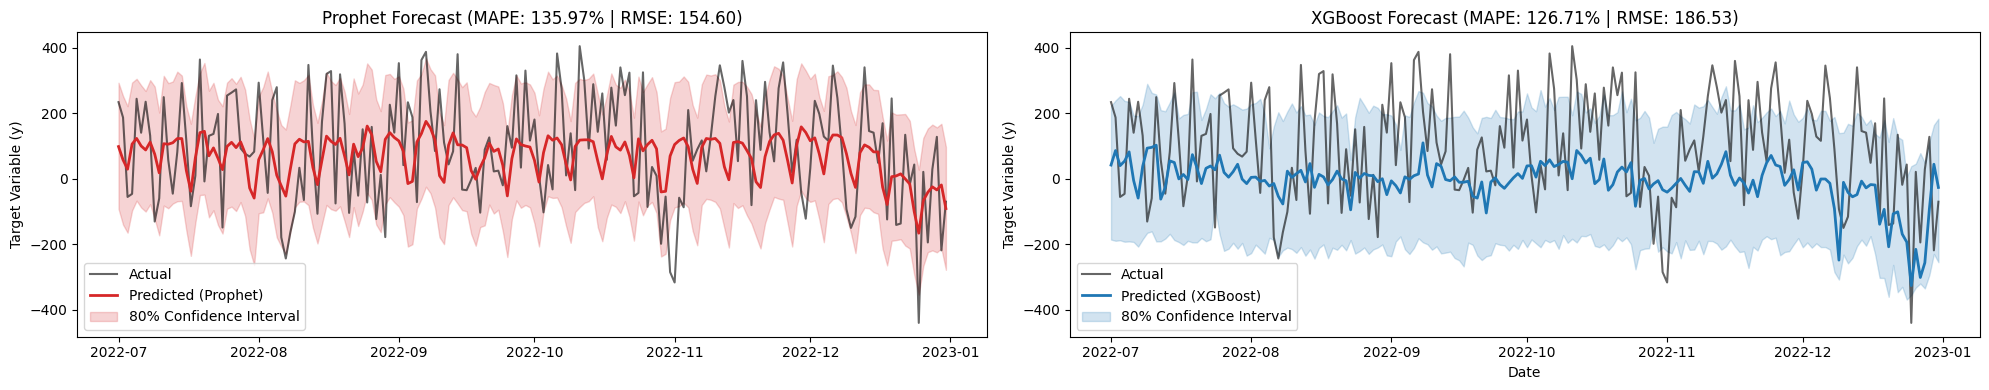

In [18]:
# Prophet vs XGBoost
fig, axes = plt.subplots(1, 2, figsize=(20, 4))

# Prophet plot
axes[0].plot(y_actual.index, y_actual['y'], label='Actual', color='black', alpha=0.6, linewidth=1.5)
axes[0].plot(y_pred_aligned.index, y_pred_aligned['yhat'], label='Predicted (Prophet)', color='tab:red', linewidth=2)
axes[0].fill_between(y_actual.index, y_lower, y_upper, color='tab:red', alpha=0.2, label='80% Confidence Interval')
axes[0].set_title(f'Prophet Forecast (MAPE: {mape:.2f}% | RMSE: {rmse:.2f})')
axes[0].set_ylabel('Target Variable (y)')
axes[0].legend(loc='lower left')

# XGBoost plot
axes[1].plot(df_test.index, y_test_vals, label='Actual', color='black', alpha=0.6, linewidth=1.5)
axes[1].plot(df_test.index, y_pred_xgb, label='Predicted (XGBoost)', color='tab:blue', linewidth=2)
axes[1].fill_between(df_test.index, quantile_preds[0.1], quantile_preds[0.9], color='tab:blue', alpha=0.2, label='80% Confidence Interval')
axes[1].set_title(f'XGBoost Forecast (MAPE: {mape_xgb:.2f}% | RMSE: {rmse_xgb:.2f})')
axes[1].set_ylabel('Target Variable (y)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

# Generate Forecasts

This section uses the `Prophet` model to generate a full-year (2023) forecast for the target variable `y`. The final output consists of daily point-forecasts, with 80% and 95% confidence intervals, for the period of Jan 1 - Dec 31, 2023. This output is aggregated at the monthly level to highlight long-term trends.

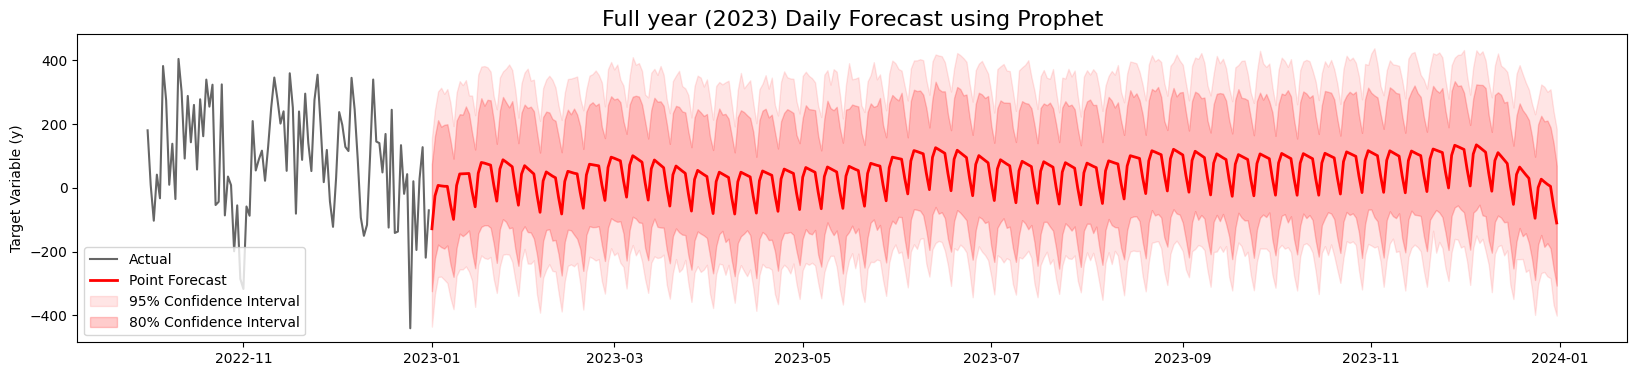

In [19]:
# Use df_combined to re-fit the Prophet model
train_full = df_combined[['x1', 'x3', 'x4', 'x5', 'y']].reset_index().rename(columns={'date': 'ds', 'y': 'y'})
train_full['x4'] = np.log1p(train_full['x4'])
train_full['x5'] = np.log1p(train_full['x5'])

# Re-fit Prophet for 95% CI and 80% CI
model_95 = Prophet(yearly_seasonality=True, weekly_seasonality=True, \
                   daily_seasonality=False, seasonality_mode='additive', \
                   interval_width=0.95)
model_80 = Prophet(yearly_seasonality=True, weekly_seasonality=True, \
                   daily_seasonality=False, seasonality_mode='additive', \
                   interval_width=0.80)

for m in [model_95, model_80]:
    for reg in regressors:
        m.add_regressor(reg)
    m.fit(train_full)

# Prophet requires future data frame to predict, here I'm using the last value to generate a data frame for 2023
future_2023 = model_95.make_future_dataframe(periods=365, freq='D')
for reg in regressors:
    last_val = train_full[reg].iloc[-1]
    future_2023[reg] = last_val

forecast_95 = model_95.predict(future_2023)
forecast_80 = model_80.predict(future_2023)

# For plotting, we will show the full 2023 forecast and Q4 2022 for the actual
mask_2023 = (forecast_95['ds'] >= '2023-01-01') & (forecast_95['ds'] <= '2023-12-31')
fc_95 = forecast_95.loc[mask_2023]
fc_80 = forecast_80.loc[mask_2023]

hist_mask = (train_full['ds'] >= '2022-10-01')
history_plot = train_full.loc[hist_mask]

# Overlay actuals, forecast, and intervals
plt.figure(figsize=(20, 4))

plt.plot(history_plot['ds'], history_plot['y'], label='Actual', color='black', alpha=0.6, linewidth=1.5)

plt.plot(fc_95['ds'], fc_95['yhat'], label='Point Forecast', color='red', linewidth=2)

plt.fill_between(fc_95['ds'], fc_95['yhat_lower'], fc_95['yhat_upper'], color='red', alpha=0.1, label='95% Confidence Interval')
plt.fill_between(fc_80['ds'], fc_80['yhat_lower'], fc_80['yhat_upper'], color='red', alpha=0.2, label='80% Confidence Interval')

plt.title('Full year (2023) Daily Forecast using Prophet', fontsize=16)
plt.ylabel('Target Variable (y)')
plt.legend(loc='lower left')
plt.show()

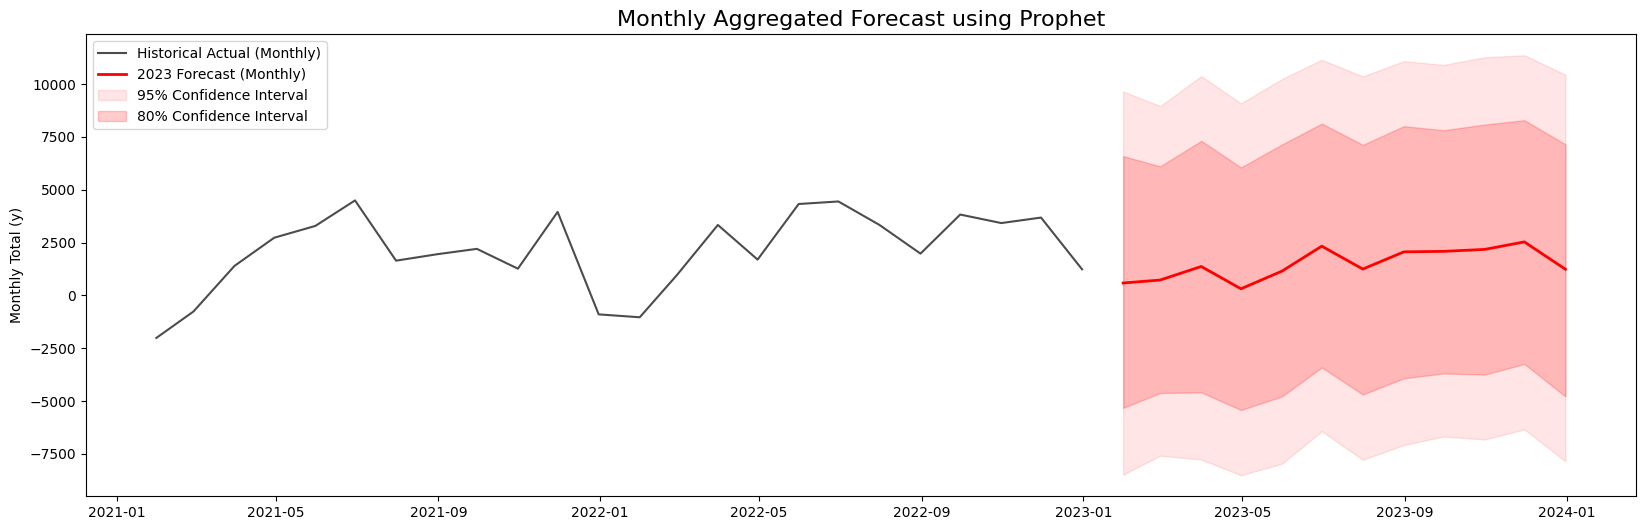

In [20]:
# Aggregate by month
hist_monthly = df_combined[['y']].resample('M').sum()
hist_monthly = hist_monthly[hist_monthly.index >= '2021-01-01']

# We use the full forecast dataframes from the previous code block
fc_95_monthly = forecast_95.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']].resample('M').sum()
fc_80_monthly = forecast_80.set_index('ds')[['yhat_lower', 'yhat_upper']].resample('M').sum()

# Filter for 2023 only for the forecast part of the plot
fc_95_2023 = fc_95_monthly[fc_95_monthly.index >= '2023-01-01']
fc_80_2023 = fc_80_monthly[fc_80_monthly.index >= '2023-01-01']

# Overlay monthly actuals, forecast, and confidence intervals
plt.figure(figsize=(20, 6))

plt.plot(hist_monthly.index, hist_monthly['y'], label='Historical Actual (Monthly)', color='black', alpha=0.7)

plt.plot(fc_95_2023.index, fc_95_2023['yhat'], label='2023 Forecast (Monthly)', color='red', linewidth=2)

plt.fill_between(fc_95_2023.index, fc_95_2023['yhat_lower'], fc_95_2023['yhat_upper'],
                 color='red', alpha=0.1, label='95% Confidence Interval')
plt.fill_between(fc_80_2023.index, fc_80_2023['yhat_lower'], fc_80_2023['yhat_upper'],
                 color='red', alpha=0.2, label='80% Confidence Interval')

plt.title('Monthly Aggregated Forecast using Prophet', fontsize=16)
plt.ylabel('Monthly Total (y)')
plt.legend(loc='upper left')
plt.show()

# Key Findings & Actionable Insights

### Model Reliability
* `Prophet` outperformed `XGBoost` and other univariate benchmark models by leveraging the information from other (exogenous?) predictor variables (`x1`, `x3`, `x4`, `x5`). Which may suggest that the target variable `y` is influenced by external factors rather than just its own historical values.
* The model is more robust against the noise and maintains the least error across the test set.

### Seasonal Patterns
* Predicted values for 2023 show a ramp-up in `y` during the summer months (Q2-Q3) (relatively similar behavior as `x1` and `x2`). Conversely, the forecast indicates a cooling-off period in late Q4 and early Q1. Resource allocation should be optimized to scale down during these periods to prevent over-capacity.

### Uncertainty
* The widening of confidence intervals during peak periods suggests higher volatility. If this forecast will be used for strategic planning, some action items might include 'buffer' capacities to account for the upper bounds of these intervals.

### Monitoring
* Since the forecast depends on `x` variables, business units should prioritize real-time monitoring of these regressors to adjust the forecast dynamically.
* Use the monthly aggregated forecast for long-term financial budgeting, but rely on the daily point forecast for short-term labor and resource scheduling.

# Proposed Framework for Developing Robust Forecasting Models

To ensure reliability and accuracy in business-critical forecasts, the following framework and best practices are recommended:

### 1. Establish a Baseline (Benchmarking)
* Always start with **univariate benchmark models** (e.g., Naive, Seasonal Naive, ETS).
* A complex multivariate model is only valuable if it significantly outperforms these simpler baselines.

### 2. Feature Engineering
* Use Variance Inflation Factor (VIF) or other multicollinearity diagnostic approaches to identify redundant predictors.
* Incorporate external drivers only if they have a logical (and maybe even statistical) relationship with the target variable.
* Apply transformations to variables that operate on different magnitudes to prevent model bias (I mostly used log-transformation but other robust methods are equally reliable e.g. Box-Cox transformation, n-order differencing, etc.).

### 3. Evaluation Metrics
* Always evaluate models using an out-of-sample test set.
* Use a range of evaluation metrics like **MAPE** (for percentage-based error relative to scale), **RMSE** (to penalize large outliers) among others, to get a holistic view of performance.

### 4. Always account for Uncertainty
* Never rely solely on point forecasts. Always generate **Confidence Intervals** (e.g., 80% and 95%) to visualize the range of probable outcomes (and ultimately manage risk).

### 5. Monitor and Iterate
* As new actual data for regressors and regressand become available, re-fit or update the model to reflect current trends. Depending on the use-case, this can be done more or less frequently (e.g. once a month, once a year, etc.).
* Lastly, periodically review where the model failed (e.g., during specific holidays or events) and incorporate those as special seasonal components.